In [1]:
import pandas as pd 
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [2]:
def std_err(arr):
    err = np.nanstd(arr,axis=0)/np.sqrt(np.sum(~np.isnan(arr),axis=0))
    return err

In [3]:
fpath = 'data/TPN1_FMIN_inhibition_260322.xlsx'

xls = pd.ExcelFile(fpath)
sheets = xls.sheet_names   # ['retinal (-)', 'retinal (+)']

data_df = {}
for s in sheets:
    df = pd.read_excel(fpath, sheet_name=s)
    data_df[s] = df

# body part condition 이름
conds = data_df[sheets[0]].columns

mean_df = pd.DataFrame(index=conds, columns=sheets)
err_df = pd.DataFrame(index=conds, columns=sheets)

for s, df in data_df.items():
    mean_df[s] = df.mean(axis=0, skipna=True)
    err_df[s] = df.apply(lambda x: x.dropna().sem(), axis=0)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

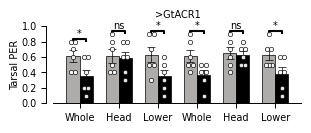

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.2, 1))

conds = [
    'SS48944>GtACR1 whole body',
    'SS48944>GtACR1 head',
    'SS48944>GtACR1 lower body',
    'R30A08>GtACR1 whole body',
    'R30A08>GtACR1 head',
    'R30A08>GtACR1 lower body'
]

groups = ['retinal -', 'retinal +']

ax, stat_all = draw_paired_bar_figure(
    data=data_df,
    mean_df=mean_df,
    err_df=err_df,
    bar_width=0.1,
    bar_spacing=.3,
    stat_fontsize=7,
    linewidth=.5,
    fontsize=7,
    dot_size=10,
    ax=ax,
    conds=conds,
    groups=groups,
    get_values=lambda data, cond, group: data[group][cond].dropna().values,
    stat_pairs=[
        ((cond, 'retinal -'), (cond, 'retinal +'))
        for cond in conds
    ],
    colors=['#AEACAB', 'black'],
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.replace('>GtACR1 ', '\n'),
    ylim=(0, 1),
    yticks=np.round(np.arange(0, 1.1, .2), 2)
)

bar_spacing = .3
num_bars = len(conds)
x_loc = np.arange(0, num_bars * bar_spacing, bar_spacing)

# xlabel = [
#     c.replace('>GtACR1 ', '\n')
#     for c in conds
# ]
xlabel = ['Whole','Head','Lower','Whole','Head','Lower']

ax.set_xticks(x_loc)
ax.set_xticklabels(xlabel, fontsize=7, rotation=0)

ax.set_yticks(np.arange(0, 1.1, .2))
ax.set_yticklabels(np.round(np.arange(0, 1.1, .2), 2), fontsize=7)

ax.set_ylabel('Tarsal PER', fontsize=7, labelpad=1)
ax.set_ylim([0, 1])
ax.set_xlim(-0.2, (num_bars - 1) * bar_spacing + 0.2)

ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_position(('outward', 5))

ax.set_title('>GtACR1', fontsize=7)
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    
# plt.savefig('figures/TPN1_silencing_tarsal.svg')

In [12]:
stat_all

[(30.0, 0.030428225023950876),
 (20.0, 0.40359098296027557),
 (29.0, 0.04291938991300753),
 (31.0, 0.0200621286326779),
 (19.0, 0.46752152313934564),
 (30.0, 0.031130560367111485)]